In [ ]:
##importing numpy pandas
import pandas as pd
import numpy as np

def creatingDataFrame():

    ##current dataset abs path
    # path="/home/dreams/PycharmProjects/PycharmProjects/webScraping/IntroductionMachineLearning/dataset/spotifyDataset/spotify_churn_dataset.csv"
    #defining new path
    path="/home/dreams/Projects/webScraping/IntroductionMachineLearning/dataset/spotifyDataset/spotify_churn_dataset.csv"

    # ##reading dataset
    dataset=pd.read_csv(path)
    # print(dataset)
    ##creating dataframe
    dfAge=pd.DataFrame(data={
        "gender":dataset['gender'],
        "age":dataset['age'],
        'country':dataset['country'],
        "listeningTime":dataset['listening_time'],
        'subscriptionType':dataset['subscription_type'],                   
    })



    dfListen=pd.DataFrame({  
        'deviceType':dataset['device_type'],
        "listeningTime":dataset['listening_time'],
        "songsPlayedPerDay":dataset['songs_played_per_day'],
        'skipRate':dataset['skip_rate'],
        'adsListenedPerWeek':dataset['ads_listened_per_week'],
        'offlineListening':dataset['offline_listening'],
    })

    #looking up dataset columns
    return dfAge,dfListen

    # dfAge.dropna(inplace=True,ignore_index=True)
    # dfListen.dropna(inplace=True,ignore_index=True)

    # dfAge.info()
    # dfListen.info()



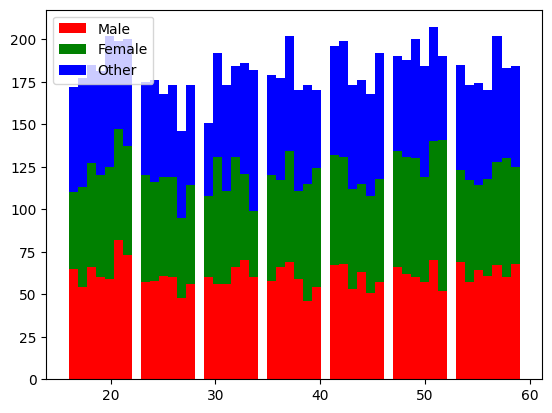

In [ ]:
def datavisualization(dfAge,dfListen):

    ## it isn't correct

    import matplotlib.pyplot as plt
    import numpy  as np
    import pandas as pd

    # print(dfAge[dfAge['Gender']=='Male']['Age'])


    x1=dfAge[dfAge['gender']=='Male']['age']
    x2=dfAge[dfAge['gender']=='Female']['age']
    x3=dfAge[dfAge['gender']=='Other']['age']




    plt.figure()
    plt.hist([x1,x2,x3],stacked=True,color=['r','g','b'],bins=50)
    plt.legend(['Male','Female','Other'],loc='upper left')
    plt.show()


    # print(df)
dfAge,dfListen=creatingDataFrame()
# datavisualization(dfAge,dfListen)


In [ ]:
def dataEncoding():
    ##creating model 
    from sklearn.preprocessing import LabelEncoder

    ##look up unnumeric data and encode unnumeric data
    #dfAge.info()
    dfAge['gender']=LabelEncoder().fit_transform(dfAge['gender'])
    dfAge['country']=LabelEncoder().fit_transform(dfAge['country'])
    dfAge['subscriptionType']=LabelEncoder().fit_transform(dfAge['subscriptionType'])
    # dfAge.to_csv("example.csv")
    
    return dfAge



def dataPreprocessing(dfAge,dfListen):
    
    dataEncoding()
    ##importing required libraries
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import MinMaxScaler,StandardScaler

    ##defining normalization objects
    scaler=StandardScaler()
    minMaxScaler=MinMaxScaler()# Sscale down all featuers to a same range.

    selectedFeatures=['age','country','listeningTime','subscriptionType']

    X=dfAge[selectedFeatures]
    y=dfAge['gender']

    #reshaping current dataset  to 2D array shape
    # nx,ny=X.shape
    # X=X.reshape((nx*ny))

    # print(X.shape)

    xTrain,xTest,yTrain,yTest=train_test_split(X,y,test_size=0.2,random_state=42)
    # normalization with MinMaxScaler
    xTrainMinMax = minMaxScaler.fit_transform(xTrain[selectedFeatures])
    xTestMinMax  = minMaxScaler.fit_transform(xTest[selectedFeatures])



    # print("X train min max scaler array shape",xTrainMinMax.shape)
    # print("X test min max scaler array shape",xTestMinMax.shape)
    # print(xTestMinMax)

    return xTrainMinMax,xTestMinMax,yTrain,yTest

#     return xTrainMinMax,xTestMinMax,yTrain,yTest
xTrainMinMax,xTestMinMax,yTrain,yTest=dataPreprocessing(dfAge,dfListen)
# print(xTrainMinMax,xTestMinMax,yTrain,yTest)


[[0.48837209 1.         0.43252595 0.        ]
 [0.69767442 0.         0.76816609 1.        ]
 [0.1627907  0.28571429 0.01730104 0.        ]
 ...
 [0.69767442 0.         0.83737024 1.        ]
 [0.02325581 1.         0.43598616 0.        ]
 [0.8372093  0.14285714 0.         1.        ]] [[0.11627907 0.14285714 0.60207612 0.66666667]
 [0.1627907  1.         0.77508651 0.66666667]
 [0.90697674 1.         0.07958478 1.        ]
 ...
 [0.90697674 0.57142857 0.58823529 0.33333333]
 [0.34883721 0.42857143 0.96885813 0.33333333]
 [0.55813953 0.42857143 0.01384083 1.        ]] 1467    2
5768    0
5714    1
1578    1
6958    2
       ..
5226    0
5390    2
860     1
7603    0
7270    2
Name: gender, Length: 6400, dtype: int64 2215    0
2582    2
1662    2
3027    2
4343    0
       ..
1079    2
7979    1
1115    2
6093    2
6832    1
Name: gender, Length: 1600, dtype: int64


In [ ]:
def creatingModel():
    from sklearn.pipeline import make_pipeline
    from sklearn.linear_model import SGDClassifier
    from sklearn.preprocessing import StandardScaler
    model=make_pipeline(
        StandardScaler(),
        SGDClassifier(
            loss='log_loss',
            penalty='l2',
            alpha=0.0001,
            learning_rate="optimal",
            
        )    
    )
    return model

# model=creatingModel()


In [ ]:
def modelTrainingAndEvulation(model,xTrainMinMax,xTestMinMax,yTrain,yTest)->object:

    from sklearn.metrics import accuracy_score,classification_report
    ##fitting current model
    fitting=model.fit(xTrainMinMax,yTrain)
    print(fitting)
    # yield fitting
    #predictions
    predictions=model.predict(xTestMinMax)
    # yield predictions
    print(predictions)

    print(classification_report(yTest,predictions))
    print("Predicted labels:",predictions)
    print("Accuracy:",accuracy_score(yTest,predictions))
    
    return fitting

# modelTrainingAndEvulation(model,xTrainMinMax,xTestMinMax,yTrain,yTest)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('sgdclassifier', SGDClassifier(loss='log_loss'))])
[1 2 0 ... 0 2 0]
              precision    recall  f1-score   support

           0       0.33      0.46      0.38       512
           1       0.34      0.24      0.28       555
           2       0.33      0.31      0.32       533

    accuracy                           0.33      1600
   macro avg       0.33      0.33      0.33      1600
weighted avg       0.33      0.33      0.32      1600

Predicted labels: [1 2 0 ... 0 2 0]
Accuracy: 0.330625


,steps,"[('standardscaler', ...), ('sgdclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'log_loss'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15


In [ ]:
# Seriliazation model
def serilization(model):
    ##Saving current model
    import pickle
    pickle.dump(model,open("spotify_model.pkl","wb"))
    print('done')

# serilization(model)


done
